# 11: End-to-End Automated 3D Object Isolation Pipeline

This notebook implements the complete pipeline from a raw Aria VRS recording to isolated 3D meshes of objects of interest.

### Pipeline stages:
1. **VRS Loading & Frame Extraction** — Decode the recording, extract RGB frames at 5 fps.
2. **Eye-Gaze Alignment** — Load MPS eye-gaze data, align temporally with RGB frames.
3. **Gaze Projection & Fixation Detection** — Project gaze to 2D, detect sustained fixations via I-DT.
4. **SAM2 Segmentation** — Generate masks using multi-run mono-prompt strategy (one SAM2 session per fixation).
5. **Image Preprocessing** — Crop distortion borders for Nerfstudio compatibility.
6. **Pose Estimation** — Run COLMAP via `ns-process-data`.
7. **NeRF Training** — Train a Nerfacto model on the scene.
8. **Geometry Export** — Export dense mesh from the trained model.
9. **Semantic Projection** — Project SAM2 masks onto mesh vertices using Nerfstudio pipeline cameras with majority voting.
10. **Subject Isolation** — Extract a clean sub-mesh containing only the voted subject vertices and faces.

As a sample, we will use the `table_objects.vrs` recordings which will be downsampled to 5 FPS.

## 11.1 Recording Configuration & Setup

All paths are derived from a single `RECORDING_NAME`.

In [3]:
import os, sys, glob, gc, math, time, subprocess
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from PIL import Image
from projectaria_tools.core import data_provider, mps
from projectaria_tools.core.sensor_data import TimeDomain

# Recording identifier
RECORDING_NAME = "table_objects"
PROJECT_ROOT_ABS = r"c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1"

# Input paths
DATA_ROOT = os.path.join("..", "data", "raw", RECORDING_NAME)
VRS_PATH  = os.path.join(DATA_ROOT, f"{RECORDING_NAME}.vrs")
MPS_ROOT  = os.path.join(DATA_ROOT, f"mps_{RECORDING_NAME}_vrs")
GAZE_DIR  = os.path.join(MPS_ROOT, "eye_gaze")
GAZE_CSV  = os.path.join(GAZE_DIR, "general_eye_gaze.csv")

# Segmentation output
SEG_ROOT   = os.path.join("..", "data", "outputs", "segmentation", RECORDING_NAME)
FRAMES_DIR = os.path.join(SEG_ROOT, "frames_5fps")
MASKS_DIR  = os.path.join(SEG_ROOT, "sam2", "masks")

# Nerfstudio pipeline
NS_ROOT       = os.path.join("..", "data", "outputs", "nerfstudio", RECORDING_NAME)
IMAGES_CROPPED = os.path.join(NS_ROOT, "images_cropped")
TRAINING_DIR   = os.path.join(NS_ROOT, "training")
EXPORT_DIR     = os.path.join(NS_ROOT, "exports")

for d in [FRAMES_DIR, MASKS_DIR, IMAGES_CROPPED, TRAINING_DIR, EXPORT_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

# Validate VRS
for label, path in {"VRS": VRS_PATH, "Gaze CSV": GAZE_CSV}.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label} not found: {os.path.abspath(path)}")

print(f"Recording: {RECORDING_NAME}")
print(f"VRS: {os.path.abspath(VRS_PATH)}")
print(f"Frames: {os.path.abspath(FRAMES_DIR)}")
print(f"Masks: {os.path.abspath(MASKS_DIR)}")
print(f"NS root: {os.path.abspath(NS_ROOT)}")

Recording: table_objects
VRS: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\table_objects\table_objects.vrs
Frames: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\table_objects\frames_5fps
Masks: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\table_objects\sam2\masks
NS root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\table_objects


### 11.1.1 VRS Access & Frame Extraction at 5 fps

Open the VRS, extract every 6th RGB frame (30 fps to 5 fps), and save as JPEG.

In [4]:
provider = data_provider.create_vrs_data_provider(VRS_PATH)
rgb_stream_id = provider.get_stream_id_from_label("camera-rgb")
rgb_config = provider.get_image_configuration(rgb_stream_id)
n_rgb_total = provider.get_num_data(rgb_stream_id)
IMG_W, IMG_H = rgb_config.image_width, rgb_config.image_height

print(f"RGB stream: {rgb_stream_id} | {n_rgb_total} frames | {IMG_W}x{IMG_H}")

RGB stream: 214-1 | 2764 frames | 1408x1408


In [5]:
def extract_rgb_frame(provider, stream_id, index):
    """Read one RGB frame from VRS by index, return as HxWx3 uint8 numpy array."""
    sample = provider.get_sensor_data_by_index(stream_id, index)
    for attr in ["image_data_and_record", "image_data", "image"]:
        if not hasattr(sample, attr):
            continue
        payload = getattr(sample, attr)
        payload = payload() if callable(payload) else payload
        if isinstance(payload, tuple):
            payload = payload[0]
        for arr_attr in ["to_numpy_array", "buffer"]:
            if hasattr(payload, arr_attr):
                arr = getattr(payload, arr_attr)
                arr = arr() if callable(arr) else arr
                arr = np.asarray(arr)
                if arr.ndim >= 2:
                    if arr.ndim == 3 and arr.shape[0] in (1, 3) and arr.shape[-1] not in (1, 3):
                        arr = np.transpose(arr, (1, 2, 0))
                    return arr.astype(np.uint8)
    raise RuntimeError(f"Cannot extract image at index {index}")

# Validate
test = extract_rgb_frame(provider, rgb_stream_id, 0)
print(f"Extraction OK: {test.shape}")

Extraction OK: (1408, 1408, 3)


In [6]:
SUBSAMPLE_STRIDE = 6  # 30fps / 6 = 5fps
FPS = 5.0

indices_5fps = list(range(0, n_rgb_total, SUBSAMPLE_STRIDE))
n_frames_5fps = len(indices_5fps)
print(f"Subsampling: stride={SUBSAMPLE_STRIDE} -> {n_frames_5fps} frames at {FPS} fps")

existing = len([f for f in os.listdir(FRAMES_DIR) if f.endswith(".jpg")])
if existing >= n_frames_5fps:
    print(f"Already extracted ({existing} files), skipping.")
else:
    for out_idx, vrs_idx in enumerate(indices_5fps):
        frame = extract_rgb_frame(provider, rgb_stream_id, vrs_idx)
        Image.fromarray(frame).save(os.path.join(FRAMES_DIR, f"{out_idx:06d}.jpg"), quality=95)
        if (out_idx + 1) % 100 == 0:
            print(f"  [{out_idx+1}/{n_frames_5fps}]")
    print(f"[OK] {n_frames_5fps} frames saved.")

Subsampling: stride=6 -> 461 frames at 5.0 fps
Already extracted (461 files), skipping.


In [7]:
# Build 5fps timestamp array
rgb_timestamps_ns_30fps = np.array([
    provider.get_sensor_data_by_index(rgb_stream_id, i).get_time_ns(TimeDomain.DEVICE_TIME)
    for i in range(n_rgb_total)], dtype=np.int64)

rgb_timestamps_ns = rgb_timestamps_ns_30fps[indices_5fps]
rgb_duration_s = (rgb_timestamps_ns[-1] - rgb_timestamps_ns[0]) / 1e9
rgb_rate_hz = len(rgb_timestamps_ns) / rgb_duration_s
print(f"5fps frames: {len(rgb_timestamps_ns)} | Duration: {rgb_duration_s:.2f}s | Rate: {rgb_rate_hz:.2f} Hz")

5fps frames: 461 | Duration: 91.99s | Rate: 5.01 Hz


## 11.2 Eye Gaze Loading & Temporal Alignment

Load the MPS gaze stream (~10 fps), align to the 5 fps RGB frames via nearest-timestamp matching.

In [8]:
eye_gazes = mps.read_eyegaze(GAZE_CSV)
n_gaze = len(eye_gazes)
assert n_gaze > 0, "Empty gaze CSV"
print(f"Gaze samples: {n_gaze}")

# Resolve timestamp accessor
g0 = eye_gazes[0]
if hasattr(g0, "tracking_timestamp") and hasattr(g0.tracking_timestamp, "total_seconds"):
    gaze_timestamps_ns = np.array([int(g.tracking_timestamp.total_seconds()*1e9) for g in eye_gazes], dtype=np.int64)
elif hasattr(g0, "tracking_timestamp_us"):
    gaze_timestamps_ns = np.array([g.tracking_timestamp_us * 1000 for g in eye_gazes], dtype=np.int64)
else:
    raise AttributeError("Unknown timestamp format")

gaze_rate_hz = n_gaze / ((gaze_timestamps_ns[-1] - gaze_timestamps_ns[0]) / 1e9)
print(f"Gaze rate: {gaze_rate_hz:.1f} Hz | RGB rate: {rgb_rate_hz:.1f} Hz")

# Resolve yaw/pitch accessor
if hasattr(g0, "yaw"):
    get_yaw, get_pitch = (lambda g: g.yaw), (lambda g: g.pitch)
elif hasattr(g0, "yaw_rads_cpf"):
    get_yaw, get_pitch = (lambda g: g.yaw_rads_cpf), (lambda g: g.pitch_rads_cpf)
else:
    raise AttributeError("Unknown gaze direction format")

Gaze samples: 921
Gaze rate: 10.0 Hz | RGB rate: 5.0 Hz


In [9]:
# Nearest-timestamp alignment
MAX_DELTA_MS = 60.0
insert_pos = np.clip(np.searchsorted(gaze_timestamps_ns, rgb_timestamps_ns), 1, n_gaze - 1)
delta_before = np.abs(rgb_timestamps_ns - gaze_timestamps_ns[insert_pos - 1])
delta_after  = np.abs(rgb_timestamps_ns - gaze_timestamps_ns[insert_pos])
nearest_gaze_idx = np.where(delta_before < delta_after, insert_pos - 1, insert_pos)
nearest_delta_ms = np.minimum(delta_before, delta_after) / 1e6
reliable = nearest_delta_ms < MAX_DELTA_MS

alignment = pd.DataFrame({
    "frame_idx": np.arange(len(rgb_timestamps_ns)),
    "rgb_ts_ns": rgb_timestamps_ns,
    "gaze_idx": nearest_gaze_idx,
    "delta_ms": nearest_delta_ms,
    "reliable": reliable,
    "yaw_rads": [get_yaw(eye_gazes[i]) for i in nearest_gaze_idx],
    "pitch_rads": [get_pitch(eye_gazes[i]) for i in nearest_gaze_idx],
})
print(f"Aligned: {reliable.sum()}/{len(alignment)} reliable ({100*reliable.mean():.1f}%)")

Aligned: 460/461 reliable (99.8%)


## 11.3 Gaze Projection to 2D Image Plane

Convert gaze direction (yaw/pitch in CPF) to pixel coordinates on the RGB camera using the device calibration chain.

In [10]:
device_calib = provider.get_device_calibration()
rgb_calib    = device_calib.get_camera_calib("camera-rgb")
T_device_cpf = device_calib.get_transform_device_cpf()
T_rgb_device = rgb_calib.get_transform_device_camera().inverse()

def project_gaze_to_rgb(yaw_rads, pitch_rads):
    """Project a gaze direction (CPF yaw/pitch) to a 2D pixel on the RGB camera."""
    gaze_cpf = np.array([np.tan(yaw_rads), np.tan(pitch_rads), 1.0])
    gaze_rgb = T_rgb_device @ (T_device_cpf @ gaze_cpf)
    return rgb_calib.project(gaze_rgb)

print("Projection function defined.")

Projection function defined.


In [11]:
gaze_x, gaze_y, valid_flags = [], [], []
for _, row in alignment.iterrows():
    if pd.isna(row['yaw_rads']) or pd.isna(row['pitch_rads']) or not row['reliable']:
        gaze_x.append(np.nan); gaze_y.append(np.nan); valid_flags.append(False)
        continue
    px = project_gaze_to_rgb(row['yaw_rads'], row['pitch_rads'])
    if px is not None:
        u, v = px[0], px[1]
        ok = (0 <= u < IMG_W) and (0 <= v < IMG_H)
        gaze_x.append(u); gaze_y.append(v); valid_flags.append(ok)
    else:
        gaze_x.append(np.nan); gaze_y.append(np.nan); valid_flags.append(False)

alignment['gaze_x'] = gaze_x
alignment['gaze_y'] = gaze_y
alignment['valid_gaze'] = valid_flags
print(f"Valid gaze projections: {sum(valid_flags)}/{len(alignment)}")

Valid gaze projections: 460/461


## 11.4 Fixation Detection (I-DT Algorithm)

Dispersion-based fixation detection: a fixation is registered when the gaze remains within a spatial threshold for a minimum duration. Uses Manhattan dispersion and median centroid for robustness.

In [12]:
def detect_fixations_idt(df, dispersion_threshold, min_duration_frames):
    """I-DT fixation detector with Manhattan dispersion and median centroid."""
    fixations = []
    valid_mask = df['valid_gaze'].values
    xs, ys = df['gaze_x'].values, df['gaze_y'].values
    frames = df['frame_idx'].values
    n = len(frames)
    i = 0
    while i <= n - min_duration_frames:
        if not all(valid_mask[i : i + min_duration_frames]):
            i += 1; continue
        wx = xs[i : i + min_duration_frames].tolist()
        wy = ys[i : i + min_duration_frames].tolist()
        disp = (max(wx)-min(wx)) + (max(wy)-min(wy))
        if disp <= dispersion_threshold:
            j = i + min_duration_frames
            while j < n and valid_mask[j]:
                wx.append(xs[j]); wy.append(ys[j])
                if (max(wx)-min(wx))+(max(wy)-min(wy)) > dispersion_threshold:
                    wx.pop(); wy.pop(); break
                j += 1
            fixations.append({
                'start_frame': int(frames[i]), 'end_frame': int(frames[j-1]),
                'centroid_x': float(np.median(wx)), 'centroid_y': float(np.median(wy)),
                'duration_frames': j - i
            })
            i = j
        else:
            i += 1
    return fixations

print("I-DT fixation detector defined.")

I-DT fixation detector defined.


In [13]:
# Fixation parameters
FIXATION_DURATION_SEC = 4.75
FIXATION_DISPERSION_PX = 200.0
FIXATION_MIN_FRAMES = math.ceil(FIXATION_DURATION_SEC * FPS)

print(f"Thresholds: {FIXATION_DURATION_SEC}s ({FIXATION_MIN_FRAMES} frames), {FIXATION_DISPERSION_PX}px")

fixations = detect_fixations_idt(alignment, FIXATION_DISPERSION_PX, FIXATION_MIN_FRAMES)
df_fix = pd.DataFrame(fixations)
df_fix['duration_s'] = df_fix['duration_frames'] / FPS
df_fix['object_id'] = range(1, len(df_fix) + 1)

# Use the mid-frame of each fixation as the SAM2 prompt frame
df_fix['mid_frame'] = ((df_fix['start_frame'] + df_fix['end_frame']) // 2).astype(int)

df_fix = df_fix.sort_values('start_frame').reset_index(drop=True)

print(f"\nDetected {len(df_fix)} fixations:")
print(df_fix[['object_id','start_frame','mid_frame','end_frame','duration_s','centroid_x','centroid_y']].to_string(index=False))

Thresholds: 4.75s (24 frames), 200.0px

Detected 2 fixations:
 object_id  start_frame  mid_frame  end_frame  duration_s  centroid_x  centroid_y
         1           81         92        104         4.8  784.563679   718.60862
         2          360        387        415        11.2  747.599804   698.30356


### 11.4.2 Visualize Detected Fixations

Overlay each fixation centroid on the **mid-frame** of the fixation window. The mid-frame provides the most representative view of the object being fixated, and is the frame that will be used as the SAM2 prompt origin.

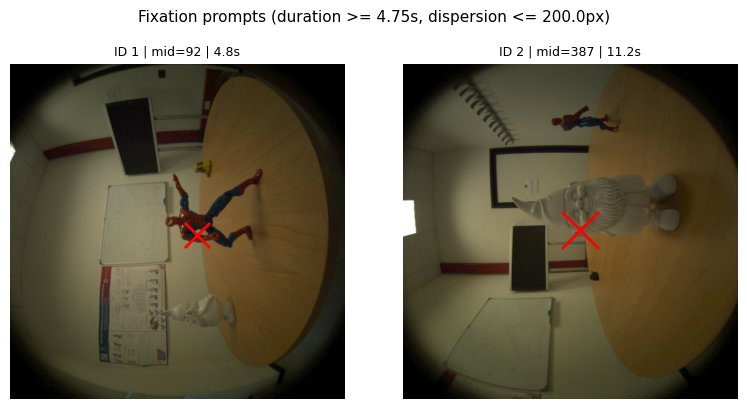

2 fixations visualized on their mid-frames.


In [14]:
import matplotlib.pyplot as plt

n_fix = len(df_fix)
cols = min(n_fix, 4)
rows = math.ceil(n_fix / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
if n_fix == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, (_, row) in enumerate(df_fix.iterrows()):
    frame_path = os.path.join(FRAMES_DIR, f"{int(row['mid_frame']):06d}.jpg")
    if not os.path.exists(frame_path):
        axes[i].set_title(f"Frame {int(row['mid_frame'])} missing", fontsize=9)
        axes[i].axis("off")
        continue

    img = np.array(Image.open(frame_path))
    axes[i].imshow(img)

    marker_size = 40 + row['duration_s'] * 60
    axes[i].scatter(row['centroid_x'], row['centroid_y'],
                    s=marker_size, c='red', marker='x', linewidths=2)

    axes[i].set_title(
        f"ID {int(row['object_id'])} | mid={int(row['mid_frame'])} | {row['duration_s']:.1f}s",
        fontsize=9)
    axes[i].axis("off")

for j in range(n_fix, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Fixation prompts (duration >= {FIXATION_DURATION_SEC}s, dispersion <= {FIXATION_DISPERSION_PX}px)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f"{n_fix} fixations visualized on their mid-frames.")

## 11.5 SAM2 Segmentation adopting Multi-Run Mono-Prompt

Each fixation is tracked independently in its own SAM2 session. This prevents inter-object interference during propagation. Per-object binary masks are merged into unified multi-label masks at the end.

In [14]:
sam2_prompts = []
for _, row in df_fix.iterrows():
    sam2_prompts.append({
        'object_id': int(row['object_id']),
        'init_frame_idx': int(row['mid_frame']),
        'point_coords': [float(row['centroid_x']), float(row['centroid_y'])],
        'point_labels': [1],
    })
for p in sam2_prompts:
    c = [round(x,1) for x in p['point_coords']]
    print(f"  ID {p['object_id']:02d} | prompt frame {p['init_frame_idx']} | {c}")

  ID 01 | prompt frame 92 | [784.6, 718.6]
  ID 02 | prompt frame 387 | [747.6, 698.3]


In [22]:
import torch
from sam2.build_sam import build_sam2_video_predictor

CHECKPOINT = os.path.join(PROJECT_ROOT_ABS, "checkpoints", "sam2_hiera_small.pt")
SAM2_CONFIG = os.path.join(PROJECT_ROOT_ABS, "third_party", "sam2", "sam2", "configs", "sam2", "sam2_hiera_s.yaml")

device = "cuda" if torch.cuda.is_available() else "cpu"
predictor = build_sam2_video_predictor(SAM2_CONFIG, CHECKPOINT, device=device)
print(f"SAM2 loaded on {device}")

SAM2 loaded on cuda


In [23]:
gc.collect(); torch.cuda.empty_cache()
inference_state = predictor.init_state(
    video_path=FRAMES_DIR, offload_video_to_cpu=True, offload_state_to_cpu=True)
predictor.reset_state(inference_state)
print(f"Video state initialized: {FRAMES_DIR}")

frame loading (JPEG): 100%|██████████| 461/461 [00:25<00:00, 17.76it/s]


Video state initialized: ..\data\outputs\segmentation\table_objects\frames_5fps


In [31]:
def run_single_prompt(predictor, state, prompt):
    """Run SAM2 forward and backward for one prompt. Returns {frame_idx: bool_mask}."""
    predictor.reset_state(state)
    predictor.add_new_points_or_box(
        inference_state=state, frame_idx=prompt['init_frame_idx'],
        obj_id=prompt['object_id'],
        points=np.array([prompt['point_coords']], dtype=np.float32),
        labels=np.array(prompt['point_labels'], dtype=np.int32))
    masks = {}
    init = prompt['init_frame_idx']
    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        for fi, _, ml in predictor.propagate_in_video(state):
            if int(fi) >= init:
                masks[int(fi)] = (ml[0,0]>0).detach().cpu().numpy()
        for fi, _, ml in predictor.propagate_in_video(state, start_frame_idx=init, reverse=True):
            if int(fi) < init:
                masks[int(fi)] = (ml[0,0]>0).detach().cpu().numpy()
    return masks

print("run_single_prompt() defined.")

run_single_prompt() defined.


In [32]:
per_object_masks = {}
for pi, prompt in enumerate(sam2_prompts):
    print(f"[{pi+1}/{len(sam2_prompts)}] Object {prompt['object_id']:02d}...", end=" ")
    t0 = time.time()
    masks = run_single_prompt(predictor, inference_state, prompt)
    per_object_masks[prompt['object_id']] = masks
    n_active = sum(1 for m in masks.values() if m.any())
    print(f"{n_active} active frames ({time.time()-t0:.1f}s)")
print("All runs complete.")

[1/2] Object 01... 

c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 93/93 [01:07<00:00,  1.38it/s]


461 active frames (244.5s)
[2/2] Object 02... 

propagate in video: 100%|██████████| 388/388 [04:44<00:00,  1.36it/s]


461 active frames (338.0s)
All runs complete.


### 11.5.2 Mask Merging & Export

In [33]:
def apply_palette_and_save(frame_idx, label_mask, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    img = Image.fromarray(label_mask, mode='P')
    pal = [0,0,0, # Background (ID 0)
        255,0,0, # red
        0,255,0, # green
        0,100,255, # blue
        255,255,0, # yellow
        255,0,255, # magenta
        0,255,255, # cyan
        255,128,0, # orange
        128,0,255, # purple
        0,255,128] # light green
    pal += [0]*(768-len(pal))
    img.putpalette(pal)
    img.save(os.path.join(output_dir, f"{int(frame_idx):06d}.png"), compress_level=1)

# Merge per-object masks into unified label masks
all_frames = set()
for m in per_object_masks.values(): all_frames.update(m.keys())
sample = next(iter(next(iter(per_object_masks.values())).values()))
h, w = sample.shape

for fi in sorted(all_frames):
    lm = np.zeros((h, w), dtype=np.uint8)
    for oid in sorted(per_object_masks):
        if fi in per_object_masks[oid]:
            lm[per_object_masks[oid][fi]] = oid
    apply_palette_and_save(fi, lm, MASKS_DIR)

print(f"[OK] {len(all_frames)} masks exported to: {MASKS_DIR}")

[OK] 461 masks exported to: ..\data\outputs\segmentation\table_objects\sam2\masks


In [24]:
# Free SAM2 from GPU
del predictor, inference_state
gc.collect(); torch.cuda.empty_cache()
print("SAM2 released.")

SAM2 released.


## 11.6 Image Preprocessing & Pose Estimation

Crop 15% borders from the 5 fps frames, then run COLMAP via `ns-process-data` to estimate camera poses.

In [79]:
CROP_PERCENT = 0.15

def apply_crop(input_dir, output_dir, ext):
    files = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(ext)])
    print(f"Cropping {len(files)} {ext} files...")
    for fn in files:
        with Image.open(os.path.join(input_dir, fn)) as img:
            w, h = img.size
            box = (w*CROP_PERCENT, h*CROP_PERCENT, w*(1-CROP_PERCENT), h*(1-CROP_PERCENT))
            img.crop(box).save(os.path.join(output_dir, fn))
    print(f"  Saved to: {output_dir}")

apply_crop(FRAMES_DIR, IMAGES_CROPPED, ".jpg")

Cropping 461 .jpg files...
  Saved to: ..\data\outputs\nerfstudio\table_objects\images_cropped


In [81]:
# Run COLMAP
sfm_cmd = ["ns-process-data", "images", "--data", IMAGES_CROPPED, "--output-dir", NS_ROOT]
print(f"Executing: {' '.join(sfm_cmd)}")

proc = subprocess.Popen(sfm_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1, encoding="utf-8", errors="replace")
for line in iter(proc.stdout.readline, ''):
    sys.stdout.write(line); sys.stdout.flush()
proc.wait()
assert proc.returncode == 0, f"COLMAP failed (exit {proc.returncode})"
print("COLMAP complete.")

Executing: ns-process-data images --data ..\data\outputs\nerfstudio\table_objects\images_cropped --output-dir ..\data\outputs\nerfstudio\table_objects
( ●    ) Copying images...
(  ●   ) Copying images...
(   ●  ) Copying images...
(    ● ) Copying images...
(     ●) Copying images...
(    ● ) Copying images...
(   ●  ) Copying images...
(  ●   ) Copying images...
( ●    ) Copying images...
(●     ) Copying images...
( ●    ) Copying images...
(   ●  ) Copying images...
(    ● ) Copying images...
(     ●) Copying images...
(    ● ) Copying images...
(   ●  ) Copying images...
(  ●   ) Copying images...
( ●    ) Copying images...
(●     ) Copying images...
( ●    ) Copying images...
(  ●   ) Copying images...
(    ● ) Copying images...
(     ●) Copying images...
(    ● ) Copying images...
(   ●  ) Copying images...
(  ●   ) Copying images...
( ●    ) Copying images...
(●     ) Copying images...
( ●    ) Copying images...
(  ●   ) Copying images...
(   ●  ) Copying images...
(    ● ) Cop

## 11.7 NeRF Training

Train a Nerfacto model as a sequence of images with associated camera poses

In [ ]:
train_cmd = [
    "ns-train", "nerfacto",
    "--data", NS_ROOT,
    "--output-dir", TRAINING_DIR,
    "--experiment-name", "nerfacto",
    "--timestamp", "2026-06-28",
]
print(f"Executing: {' '.join(train_cmd)}")

proc = subprocess.Popen(train_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1, encoding="utf-8", errors="replace")
for line in iter(proc.stdout.readline, ''):
    sys.stdout.write(line); sys.stdout.flush()
proc.wait()
print(f"Training exit code: {proc.returncode}")

Executing: ns-train nerfacto --data ..\data\outputs\nerfstudio\table_objects --output-dir ..\data\outputs\nerfstudio\table_objects\training --experiment-name nerfacto --timestamp 2026-06-28
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\utils\misc.py:183: RuntimeWarning: Windows does not yet support torch.compile and the performance will be affected.
  warnings.warn(
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\field_components\activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\field_components\activations.py:38: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
[12:15:22] Using --d

## 11.8 Geometry Export

Export a Poisson mesh from the latest training checkpoint.

In [17]:
def find_latest_config(root):
    configs = sorted(Path(root).rglob('config.yml'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not configs: raise FileNotFoundError(f"No config.yml under {root}")
    return str(configs[0].resolve())

training_dir_clean = TRAINING_DIR[TRAINING_DIR.find("data"):]
training_dir_abs = os.path.join(PROJECT_ROOT_ABS, training_dir_clean)

latest_config = find_latest_config(training_dir_abs)
print(f"Config: {latest_config}")

export_dir_clean = EXPORT_DIR[EXPORT_DIR.find("data"):]
export_dir_abs = os.path.join(PROJECT_ROOT_ABS, export_dir_clean)

mesh_dir = os.path.join(export_dir_abs, "mesh")
Path(mesh_dir).mkdir(parents=True, exist_ok=True)

Config: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\table_objects\training\nerfacto\nerfacto\2026-06-28\config.yml


In [ ]:
# export mesh using Poisson reconstruction
mesh_cmd = [
    "ns-export", "poisson",
    "--load-config", latest_config,
    "--output-dir", mesh_dir,
    "--target-num-faces", "50000",
    "--num-pixels-per-side", "2048",
    "--num-points", "1000000",
    "--remove-outliers", "True",
    "--normal-method", "open3d",
    "--obb_center", "0", "0", "0",
    "--obb_rotation", "0", "0", "0",
    "--obb_scale", "2", "2", "2"
]
print(f"Executing: {' '.join(mesh_cmd)}")

proc = subprocess.Popen(mesh_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1, encoding="utf-8", errors="replace")
for line in iter(proc.stdout.readline, ''):
    sys.stdout.write(line); sys.stdout.flush()
proc.wait()
print(f"Mesh export exit code: {proc.returncode}")

Executing: ns-export poisson --load-config C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\table_objects\training\nerfacto\nerfacto\2026-06-28\config.yml --output-dir c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\table_objects\exports\mesh --target-num-faces 50000 --num-pixels-per-side 2048 --num-points 1000000 --remove-outliers True --normal-method open3d --obb_center 0 0 0 --obb_rotation 0 0 0 --obb_scale 2 2 2
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\utils\misc.py:183: RuntimeWarning: Windows does not yet support torch.compile and the performance will be affected.
  warnings.warn(
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\field_components\activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
C:\Users\Gma

In [18]:
# Locate the exported mesh PLY
mesh_candidates = list(Path(mesh_dir).rglob("*.ply"))
if not mesh_candidates:
    raise FileNotFoundError(f"No PLY found in {mesh_dir}")
MESH_PLY = str(mesh_candidates[0])
print(f"Mesh PLY: {MESH_PLY}")

Mesh PLY: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\table_objects\exports\mesh\poisson_mesh.ply


## 11.9 Semantic Projection with Area-Filtered Majority Voting

Project SAM2 masks onto mesh vertices using the Nerfstudio pipeline cameras. **All** available masks are projected.

### Voting strategy:
1. **Area filter**: A frame votes only if the total subject mask area exceeds `MIN_MASK_AREA_PCT` of the image. This prevents frames where an object is barely visible (or absent) from diluting the vote.
2. **Relative majority**: For each vertex, the vote is relative to the number of *eligible* frames that can see it. A vertex passes if `n_subject / n_eligible >= 0.5`.

### Known limitation:
Objects with complex geometry may be only partially segmented by SAM2 in many frames. The area filter mitigates this by excluding frames with negligible mask coverage, but if SAM2 consistently segments only a portion of the object, the unsegmented portion will not pass the vote. This is a limitation of the mask quality, not the voting algorithm.

In [19]:
import torch
from pathlib import Path
from plyfile import PlyData, PlyElement

MIN_MASK_AREA_PCT = 0.5  # minimum subject mask area as % of image to allow voting

def load_ply_vertices(path):
    print(f"  Reading {os.path.basename(path)}...")
    ply = PlyData.read(path)
    v = ply["vertex"]
    xyz = np.stack([np.array(v["x"],np.float64), np.array(v["y"],np.float64),
                    np.array(v["z"],np.float64)], axis=1)
    props = {p.name for p in v.properties}
    rgb = None
    if {"red","green","blue"}.issubset(props):
        rgb = np.stack([np.array(v["red"],np.uint8), np.array(v["green"],np.uint8),
                        np.array(v["blue"],np.uint8)], axis=1).copy()
    has_faces = "face" in [e.name for e in ply.elements]
    print(f"  Vertices: {len(xyz):,} | Faces: {'yes' if has_faces else 'no'}")
    return xyz, rgb, ply

def save_ply_preserve_faces(path, ply_orig, rgb_new):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    v = ply_orig["vertex"]
    nd = np.empty(len(v.data), dtype=v.data.dtype); nd[:] = v.data[:]
    if "red" in {p.name for p in v.properties}:
        nd["red"], nd["green"], nd["blue"] = rgb_new[:,0], rgb_new[:,1], rgb_new[:,2]
    elems = [PlyElement.describe(nd, "vertex")]
    for e in ply_orig.elements:
        if e.name != "vertex": elems.append(e)
    PlyData(elems).write(path)
    print(f"  PLY saved: {path}")

def load_mask_for_proj(mask_path, W, H):
    """Load a palettized PNG mask preserving label indices (not RGB grayscale)."""
    mask = np.array(Image.open(mask_path))  # reads palette indices directly
    mh, mw = mask.shape[:2]
    if mask.ndim == 3:
        mask = mask[:,:,0]  # fallback if loaded as RGB
    ox, oy = (mw - W) // 2, (mh - H) // 2
    if ox >= 0 and oy >= 0:
        return mask[oy:oy+H, ox:ox+W]
    return cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)

def find_ns_camera(pipeline, frame_name):
    for s in ["train","eval"]:
        ds = getattr(pipeline.datamanager, f"{s}_dataset", None)
        if ds is None: continue
        for i, fn in enumerate(ds._dataparser_outputs.image_filenames):
            if frame_name in str(fn):
                return ds.cameras[i:i+1], s, i
    return None, None, None

def project_with_distortion(xyz, c2w_3x4, fx, fy, cx, cy, k1, k2, p1, p2, W, H):
    c2w = np.eye(4); c2w[:3,:] = c2w_3x4
    w2c = np.linalg.inv(c2w)
    cam = (w2c @ np.hstack([xyz, np.ones((len(xyz),1))]).T).T
    Xc, Yc, Zc = cam[:,0], cam[:,1], cam[:,2]
    depth = -Zc; ok = depth > 1e-4; sd = np.where(ok, depth, 1.0)
    xn, yn = Xc/sd, -Yc/sd
    r2 = xn**2 + yn**2; r4 = r2**2
    rad = 1 + k1*r2 + k2*r4
    xd = xn*rad + 2*p1*xn*yn + p2*(r2+2*xn**2)
    yd = yn*rad + p1*(r2+2*yn**2) + 2*p2*xn*yn
    u = (fx*xd+cx).astype(np.int32); v = (fy*yd+cy).astype(np.int32)
    valid = ok & (u>=0) & (u<W) & (v>=0) & (v<H)
    return np.stack([u,v],1), valid

print("Projection utilities defined.")
print(f"Area filter threshold: {MIN_MASK_AREA_PCT}%")

Projection utilities defined.
Area filter threshold: 0.5%


### 11.9.1 Pipeline Loading & Mesh Preparation

In [21]:
gc.collect(); torch.cuda.empty_cache()
os.chdir(PROJECT_ROOT_ABS)

from nerfstudio.utils.eval_utils import eval_setup
_, pipeline_ns, _, _ = eval_setup(Path(latest_config))
pipeline_ns.eval()
print("Pipeline loaded.")

[14:22:11] Auto image downscale factor of 1                                                 ]8;id=370643;file://c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\data\dataparsers\nerfstudio_dataparser.py\nerfstudio_dataparser.py]8;;\:]8;id=940354;file://c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\nerfstudio\data\dataparsers\nerfstudio_dataparser.py#484\484]8;;\

Started threads


Setting up evaluation dataset...

Caching all 46 images.

Output()

Loading latest checkpoint from load_dir

✅ Done loading checkpoint from 
C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\table_objects\training\nerfacto\nerfacto\2026-
06-28\nerfstudio_models\step-000029999.ckpt

Pipeline loaded.


In [22]:
os.chdir(os.path.join(PROJECT_ROOT_ABS, "notebooks"))

xyz_mesh, rgb_mesh_orig, ply_mesh = load_ply_vertices(MESH_PLY)
N_mesh = len(xyz_mesh)
if rgb_mesh_orig is None:
    rgb_mesh_orig = np.full((N_mesh,3), 180, dtype=np.uint8)
print(f"BB: {xyz_mesh.min(0).round(4)} ... {xyz_mesh.max(0).round(4)}")

  Reading poisson_mesh.ply...
  Vertices: 221,645 | Faces: yes
BB: [-1.0226 -1.016  -1.0317] ... [1.0273 1.0312 1.0195]


### 11.9.2 Mask Selection & Projection

Project a uniformly sampled subset of masks onto the mesh vertices. One mask every `PROJ_STRIDE` frames is selected automatically, giving a balanced mix of viewpoints across the recording. The majority voting threshold is computed as strict majority: `>= n_projected // 2 + 1`.

In [54]:
VOTE_THRESHOLD_PCT = 66.6

# Discover all masks
all_mask_files = sorted([f for f in os.listdir(MASKS_DIR) if f.endswith(".png")])
n_total_masks = len(all_mask_files)
print(f"Total masks: {n_total_masks}")
print(f"Vote threshold: {VOTE_THRESHOLD_PCT}%")

Total masks: 461
Vote threshold: 66.6%


In [55]:
# Per-vertex vote accumulators
n_views_seen = np.zeros(N_mesh, dtype=np.int32) # how many views see this vertex
n_subject = np.zeros(N_mesh, dtype=np.int32) # how many of those label it as subject
votes_per_label = {}

skipped_cam = 0
projected = 0

for mi, mask_name in enumerate(all_mask_files):
    mask_id = int(mask_name.replace(".png", ""))
    frame_name = f"frame_{mask_id + 1:05d}"
    mask_path = os.path.join(MASKS_DIR, mask_name)

    # Find camera
    cam, split, idx = find_ns_camera(pipeline_ns, frame_name)
    if cam is None:
        skipped_cam += 1
        continue

    # Camera parameters
    c2w = cam.camera_to_worlds[0].cpu().numpy()
    fx, fy = cam.fx[0].item(), cam.fy[0].item()
    cx, cy = cam.cx[0].item(), cam.cy[0].item()
    H, W = int(cam.height[0].item()), int(cam.width[0].item())
    dp = cam.distortion_params[0].cpu().numpy() if cam.distortion_params is not None else np.zeros(6)
    k1, k2, p1, p2 = float(dp[0]), float(dp[1]), float(dp[2]), float(dp[3])

    # Load mask (PIL to preserve palette indices)
    mask = load_mask_for_proj(mask_path, W, H)

    # Project all vertices
    uv, valid = project_with_distortion(xyz_mesh, c2w, fx, fy, cx, cy, k1, k2, p1, p2, W, H)
    valid_idx = np.where(valid)[0]

    # Track visibility
    n_views_seen[valid_idx] += 1

    # Lookup mask labels
    labels = mask[uv[valid_idx, 1], uv[valid_idx, 0]]
    subj_idx = valid_idx[labels > 0]
    n_subject[subj_idx] += 1

    for lbl in np.unique(labels):
        if lbl == 0: continue
        lbl = int(lbl)
        if lbl not in votes_per_label:
            votes_per_label[lbl] = np.zeros(N_mesh, dtype=np.int32)
        votes_per_label[lbl][valid_idx[labels == lbl]] += 1

    projected += 1
    if (mi + 1) % 50 == 0:
        print(f"  [{mi+1}/{n_total_masks}] projected={projected}")

print(f"\nProjected: {projected} | Skipped (no camera): {skipped_cam}")

C:\Users\Gmalv\AppData\Local\Temp\ipykernel_7972\3055146540.py:65: RuntimeWarning: invalid value encountered in cast
  u = (fx*xd+cx).astype(np.int32); v = (fy*yd+cy).astype(np.int32)


  [50/461] projected=50
  [100/461] projected=100
  [150/461] projected=150
  [200/461] projected=200
  [250/461] projected=250
  [300/461] projected=300
  [350/461] projected=350
  [400/461] projected=400
  [450/461] projected=450

Projected: 461 | Skipped (no camera): 0


### 11.9.3 Majority Voting & Export

A vertex is classified as subject if `>= MIN_VIEWS` independent views labelled it as such.

In [56]:
# Compute per-vertex subject ratio
safe_seen = np.maximum(n_views_seen, 1)
subject_ratio = n_subject / safe_seen
passes_mesh = (subject_ratio >= VOTE_THRESHOLD_PCT / 100.0) & (n_subject > 0)

# Determine best label
best_label_mesh = np.zeros(N_mesh, dtype=np.int32)
for lbl in sorted(votes_per_label.keys()):
    is_best = passes_mesh.copy()
    for other_lbl in votes_per_label:
        if other_lbl != lbl:
            is_best &= votes_per_label[lbl] >= votes_per_label.get(other_lbl, np.zeros(N_mesh, dtype=np.int32))
    best_label_mesh[is_best] = lbl

# Diagnostics
print(f"Vote threshold: {VOTE_THRESHOLD_PCT}%")
print(f"\nSubject ratio distribution (vertices with >= 1 subject vote):")
ratios = subject_ratio[n_subject > 0]
for pct in [10, 25, 50, 75, 90, 95]:
    print(f"  {pct}th percentile: {np.percentile(ratios, pct)*100:.1f}%")

print(f"\nVertices passing at various thresholds:")
for thr in [1, 2, 3, 4, 5, 6, 8, 10]:
    n = int(((subject_ratio >= thr/100) & (n_subject > 0)).sum())
    marker = " <-- current" if thr == VOTE_THRESHOLD_PCT else ""
    print(f"  >= {thr}%: {n:,}{marker}")

for lbl in sorted(votes_per_label.keys()):
    n = int((passes_mesh & (best_label_mesh == lbl)).sum())
    print(f"\nLabel {lbl}: {n:,} vertices")

print(f"\nTotal passing: {passes_mesh.sum():,} / {N_mesh:,}")

Vote threshold: 66.6%

Subject ratio distribution (vertices with >= 1 subject vote):
  10th percentile: 0.7%
  25th percentile: 2.1%
  50th percentile: 5.5%
  75th percentile: 18.0%
  90th percentile: 34.3%
  95th percentile: 39.8%

Vertices passing at various thresholds:
  >= 1%: 142,695
  >= 2%: 126,024
  >= 3%: 112,211
  >= 4%: 99,516
  >= 5%: 87,360
  >= 6%: 79,147
  >= 8%: 65,470
  >= 10%: 58,645

Label 1: 3,499 vertices

Label 2: 1,462 vertices

Total passing: 4,961 / 221,645


In [57]:
# Save projected mesh
MESH_PROJ_OUT = os.path.join(EXPORT_DIR, "mesh", "projected", "mesh_projected.ply")
os.makedirs(os.path.dirname(MESH_PROJ_OUT), exist_ok=True)

rgb_out = rgb_mesh_orig.copy()
LABEL_COLORS = {1: [255,0,0], 2: [0,255,0], 3: [0,100,255], 4: [255,255,0]}
for lbl, color in LABEL_COLORS.items():
    m = passes_mesh & (best_label_mesh == lbl)
    if m.any():
        rgb_out[m] = color

save_ply_preserve_faces(MESH_PROJ_OUT, ply_mesh, rgb_out)
print(f"Projected mesh: {MESH_PROJ_OUT}")

  PLY saved: ..\data\outputs\nerfstudio\table_objects\exports\mesh\projected\mesh_projected.ply
Projected mesh: ..\data\outputs\nerfstudio\table_objects\exports\mesh\projected\mesh_projected.ply


In [ ]:
# Release pipeline
# del pipeline_ns; gc.collect(); torch.cuda.empty_cache()
# print("Nerfstudio pipeline released.")

## 11.10 Subject Isolation

Extract a clean sub-mesh containing only the vertices and faces that passed the majority voting. Only faces whose **three** vertices all belong to the subject set are retained. The original vertex colors are preserved.

In [58]:
def extract_submesh(ply_orig, vertex_mask):
    """Extract sub-mesh: keep only vertices where vertex_mask is True.
    Faces are retained only if all three vertices pass. Indices are remapped."""
    v = ply_orig["vertex"]; N = len(v.data)
    idx_map = np.full(N, -1, dtype=np.int32)
    idx_map[vertex_mask] = np.arange(vertex_mask.sum(), dtype=np.int32)
    new_v = v.data[vertex_mask]
    elems = [PlyElement.describe(new_v, "vertex")]
    if "face" in [e.name for e in ply_orig.elements]:
        fd = ply_orig["face"].data
        kept = []
        for fv in fd["vertex_indices"]:
            rm = idx_map[fv]
            if np.all(rm >= 0):
                kept.append(rm)
        nf = np.empty(len(kept), dtype=[("vertex_indices","O")])
        for i, fv in enumerate(kept):
            nf["vertex_indices"][i] = np.array(fv, dtype=np.int32)
        elems.append(PlyElement.describe(nf, "face"))
        print(f"  Faces: {len(fd):,} -> {len(kept):,}")
    return PlyData(elems)

print("extract_submesh() defined.")

extract_submesh() defined.


In [59]:
ISOLATED_MESH = os.path.join(EXPORT_DIR, "mesh", "isolated", "subjects_isolated.ply")
os.makedirs(os.path.dirname(ISOLATED_MESH), exist_ok=True)

print(f"Subject vertices: {passes_mesh.sum():,} / {N_mesh:,}\n")
isolated = extract_submesh(ply_mesh, passes_mesh)
isolated.write(ISOLATED_MESH)

v = isolated["vertex"]
xyz_iso = np.stack([v["x"], v["y"], v["z"]], axis=1)
n_faces = len(isolated["face"].data) if "face" in [e.name for e in isolated.elements] else 0

print(f"\nIsolated mesh: {ISOLATED_MESH}")
print(f"Vertices: {len(xyz_iso):,} | Faces: {n_faces:,}")
print(f"BB: {xyz_iso.min(0).round(4)} ... {xyz_iso.max(0).round(4)}")

Subject vertices: 4,961 / 221,645

  Faces: 437,821 -> 9,561

Isolated mesh: ..\data\outputs\nerfstudio\table_objects\exports\mesh\isolated\subjects_isolated.ply
Vertices: 4,961 | Faces: 9,561
BB: [-0.4081 -0.5446 -0.1418] ... [-0.1073 -0.1246  0.4187]


## Pipeline Conclusions

The isolated mesh contains only the 3D geometry of objects identified through eye-tracking fixation detection. The output preserves original vertex colors and face topology.
